# cell-cell interaction analysis for Tfh17 and B mem C8


## run some quick ligand - receptor analysis


In [ ]:
# load packages
import pandas as pd
import scanpy as sc


In [2]:
import liana as li
li.__version__

'1.4.0'

In [3]:
# define path
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures/'

## do some quick preprocessing


In [ ]:
# load data
tb_adata = sc.read_h5ad(
    '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/ALTRA_aim3_T_B_mem_cells.h5ad')

In [ ]:
sc.pl.umap(
    tb_adata,  # legend_loc='on data',
    color=['cell_labels', 'AIFI_L2', 'AIFI_L3']
)

In [ ]:
# check raw counts
tb_adata

In [15]:
# save the raw counts
tb_adata.layers['counts'] = tb_adata.X.copy()

In [16]:
tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [17]:
# Normalizing to median total counts
sc.pp.normalize_total(tb_adata)
# Logarithmize the data
sc.pp.log1p(tb_adata)

In [ ]:
# %%time
sc.pp.highly_variable_genes(
    tb_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

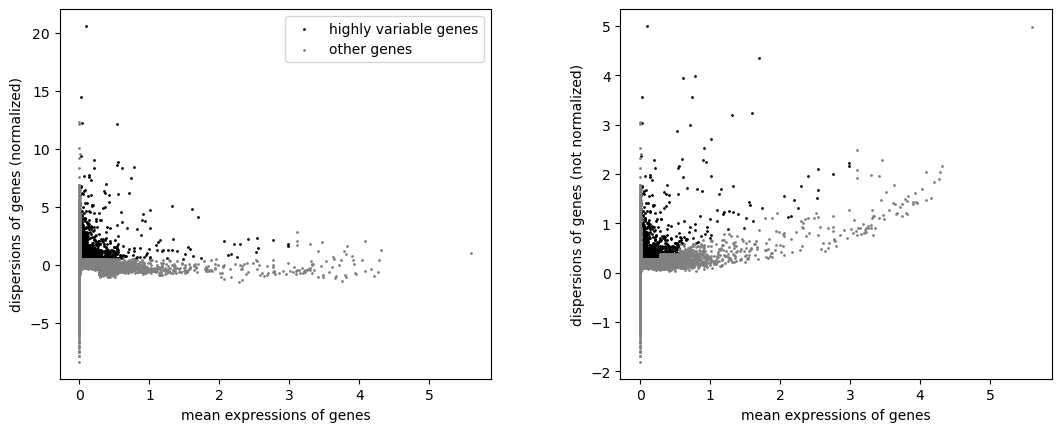

In [19]:
sc.pl.highly_variable_genes(tb_adata)

In [20]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(tb_adata, svd_solver="arpack", mask_var="highly_variable")

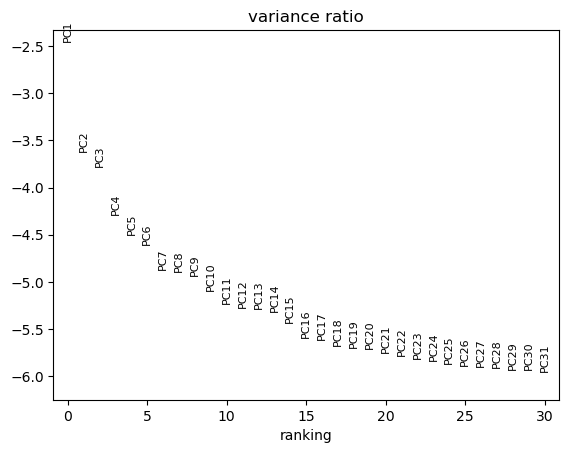

In [21]:
# plot the principle component variance explained
sc.pl.pca_variance_ratio(tb_adata, log=True)

In [22]:
# run umap
sc.pp.neighbors(tb_adata, n_pcs=15, use_rep='X_pca')
sc.tl.umap(tb_adata)

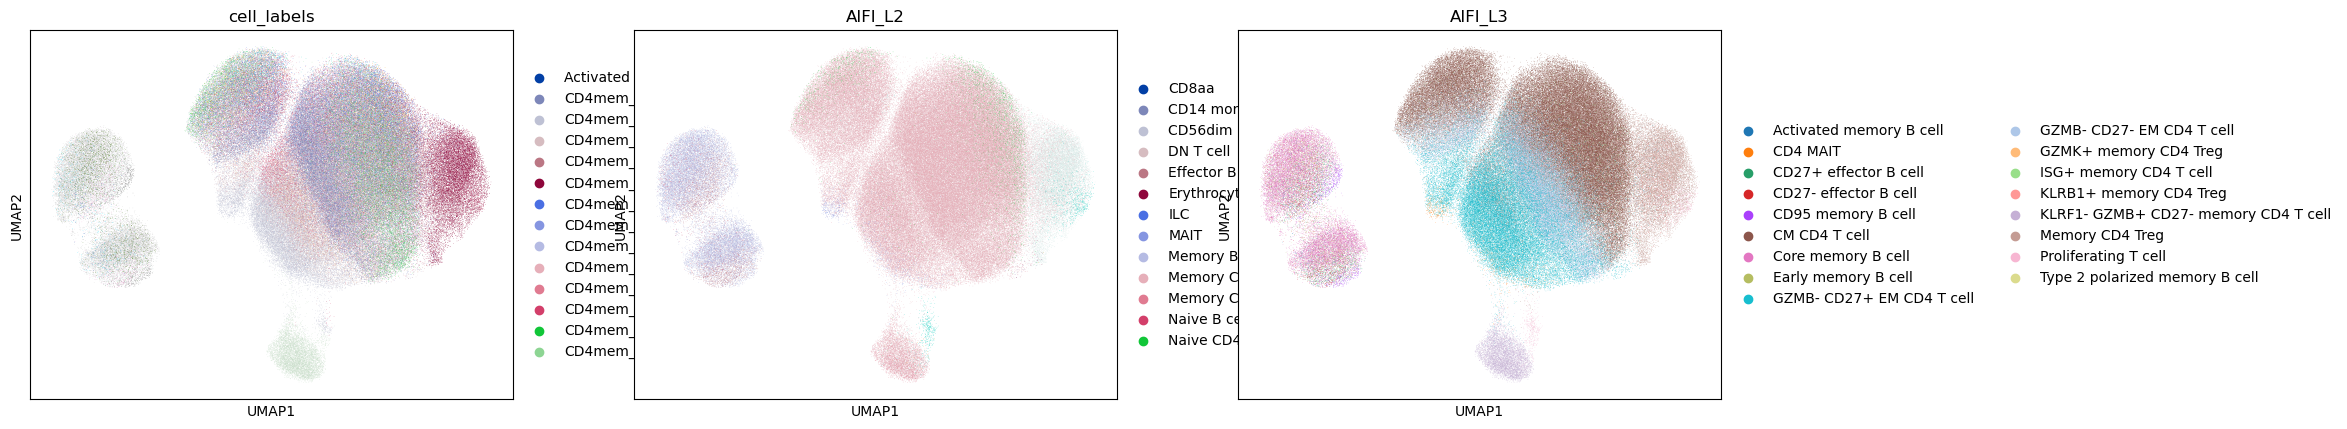

In [ ]:
sc.pl.umap(
    tb_adata,  # legend_loc='on data',
    color=['cell_labels', 'AIFI_L2', 'AIFI_L3']
)

### export the gene expressed by Tmem C3


In [ ]:
# load data
tb_adata = sc.read_h5ad(
    '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/ALTRA_aim3_T_B_mem_cells.h5ad')


In [ ]:
# tb_adata.X[1:50, 1:50].toarray()

In [20]:
tb_adata.obs['cell_labels'].unique().tolist()

['CD27+ effector B cell',
 'CD4mem_C11',
 'CD4mem_C7',
 'CD4mem_C5',
 'CD4mem_C10',
 'CD4mem_C3',
 'CD4mem_C12',
 'CD4mem_C9',
 'CD4mem_C6',
 'CD4mem_C14',
 'CD4mem_C15',
 'CD4mem_C8',
 'CD4mem_C16',
 'CD4mem_C18',
 'CD4mem_C0',
 'CD4mem_C4',
 'CD4mem_C1',
 'CD4mem_C17',
 'CD4mem_C2',
 'CD4mem_C13',
 'CD27- effector B cell',
 'CD27- effector B cell_C8',
 'CD27- effector B cell_C9',
 'Early memory B cell',
 'Core memory B cell',
 'Activated memory B cell',
 'CD95 memory B cell',
 'Type 2 polarized memory B cell']

In [8]:
tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [ ]:
def get_expressed_genes(adata, cell_type, expr_prop):
    """
    Identify genes expressed in a given cell type above a specified proportion threshold.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix (AnnData object) containing single-cell data.
    cell_type : str
        The cell type label to filter cells by (must match values in adata.obs["cell_labels"]).
    expr_prop : float
        Minimum proportion of cells expressing a gene to consider it as expressed (between 0 and 1).

    Returns
    -------
    stats : pandas.DataFrame
        DataFrame with columns:
            - 'genes': gene names
            - 'props': proportion of cells expressing each gene
            - 'cell_type': the cell type label
        Only genes with expression proportion >= expr_prop are included.
    """
    # calculate proportions
    temp = adata[adata.obs["cell_labels"] == cell_type, :]
    a = temp.layers['counts'].getnnz(axis=0) / temp.X.shape[0]
    stats = (
        pd.DataFrame({"genes": temp.var_names, "props": a})
        .assign(cell_type=cell_type)
        .sort_values("genes")
    )

    # obtain expressed genes
    stats = stats[stats["props"] >= expr_prop]
    expressed_genes = stats["genes"].values

    return stats

In [ ]:
# calculate expressed genes at 10% threshold for CD4 memory T C3
# this is used for Nichnet analysis input to filter out ligands/receptors that are not expressed in the cell type of interest
tmem_c3_genes = get_expressed_genes(tb_adata, 'CD4mem_C3', 0.1)
# export the results
tmem_c3_genes.to_csv(output_path + 'ALTRA_TmemC3_expressed_genes.csv')
tmem_c3_genes

,genes,props,cell_type
32030,A1BG,0.149114,CD4mem_C3
16365,AAED1,0.118671,CD4mem_C3
3829,AAK1,0.728354,CD4mem_C3
5117,AAMP,0.145000,CD4mem_C3
7595,AASDH,0.116266,CD4mem_C3
...,...,...,...
10493,ZSCAN16-AS1,0.183987,CD4mem_C3
27017,ZSWIM7,0.184114,CD4mem_C3
1034,ZYG11B,0.120696,CD4mem_C3
13163,ZYX,0.237848,CD4mem_C3


In [11]:
beff_c9_genes = get_expressed_genes(tb_adata, 'CD27- effector B cell_C9', 0.1)
# export the results
beff_c9_genes.to_csv(output_path + 'ALTRA_BeffC9_expressed_genes.csv')
beff_c9_genes

,genes,props,cell_type
32030,A1BG,0.159907,CD27- effector B cell_C9
16365,AAED1,0.112399,CD27- effector B cell_C9
5117,AAMP,0.151796,CD27- effector B cell_C9
18506,AASDHPPT,0.195829,CD27- effector B cell_C9
27428,AATF,0.305910,CD27- effector B cell_C9
...,...,...,...
1218,ZRANB2,0.551564,CD27- effector B cell_C9
13452,ZRSR2,0.230591,CD27- effector B cell_C9
10493,ZSCAN16-AS1,0.206257,CD27- effector B cell_C9
27017,ZSWIM7,0.192352,CD27- effector B cell_C9


In [ ]:
beff_c8_genes = get_expressed_genes(tb_adata, 'CD27- effector B cell_C9', 0.1)
# export the results
beff_c8_genes.to_csv(output_path + 'ALTRA_BeffC8_expressed_genes.csv')

## run ligand receptor interaction by individual methods


In [4]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [5]:
# load data
tb_adata = sc.read_h5ad(
    '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/ALTRA_aim3_T_B_mem_cells_liana.h5ad')
tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [11]:
tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [ ]:
# run cellphonedb
cellphonedb(tb_adata,
            groupby='cell_labels', use_raw=False,
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus', n_jobs=30,
            expr_prop=0.1, n_perms=5000,
            verbose=True, key_added='cpdb_res')

Using resource `consensus`.
Using `.X`!
/home/workspace/environment/liana/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
6747 features of mat are empty, they will be removed.
/home/workspace/environment/liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/workspace/environment/liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.14 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 247306 samples and 1573 features


 41%|████      | 2060/5000 [17:38<22:58,  2.13it/s]/home/workspace/environment/liana/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
 42%|████▏     | 2117/5000 [18:12<23:40,  2.03it/s]Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
 72%|███████▏  | 3591/5000 [32:04<10:42,  2.19it/s]Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
 90%|█████████ | 4513/5

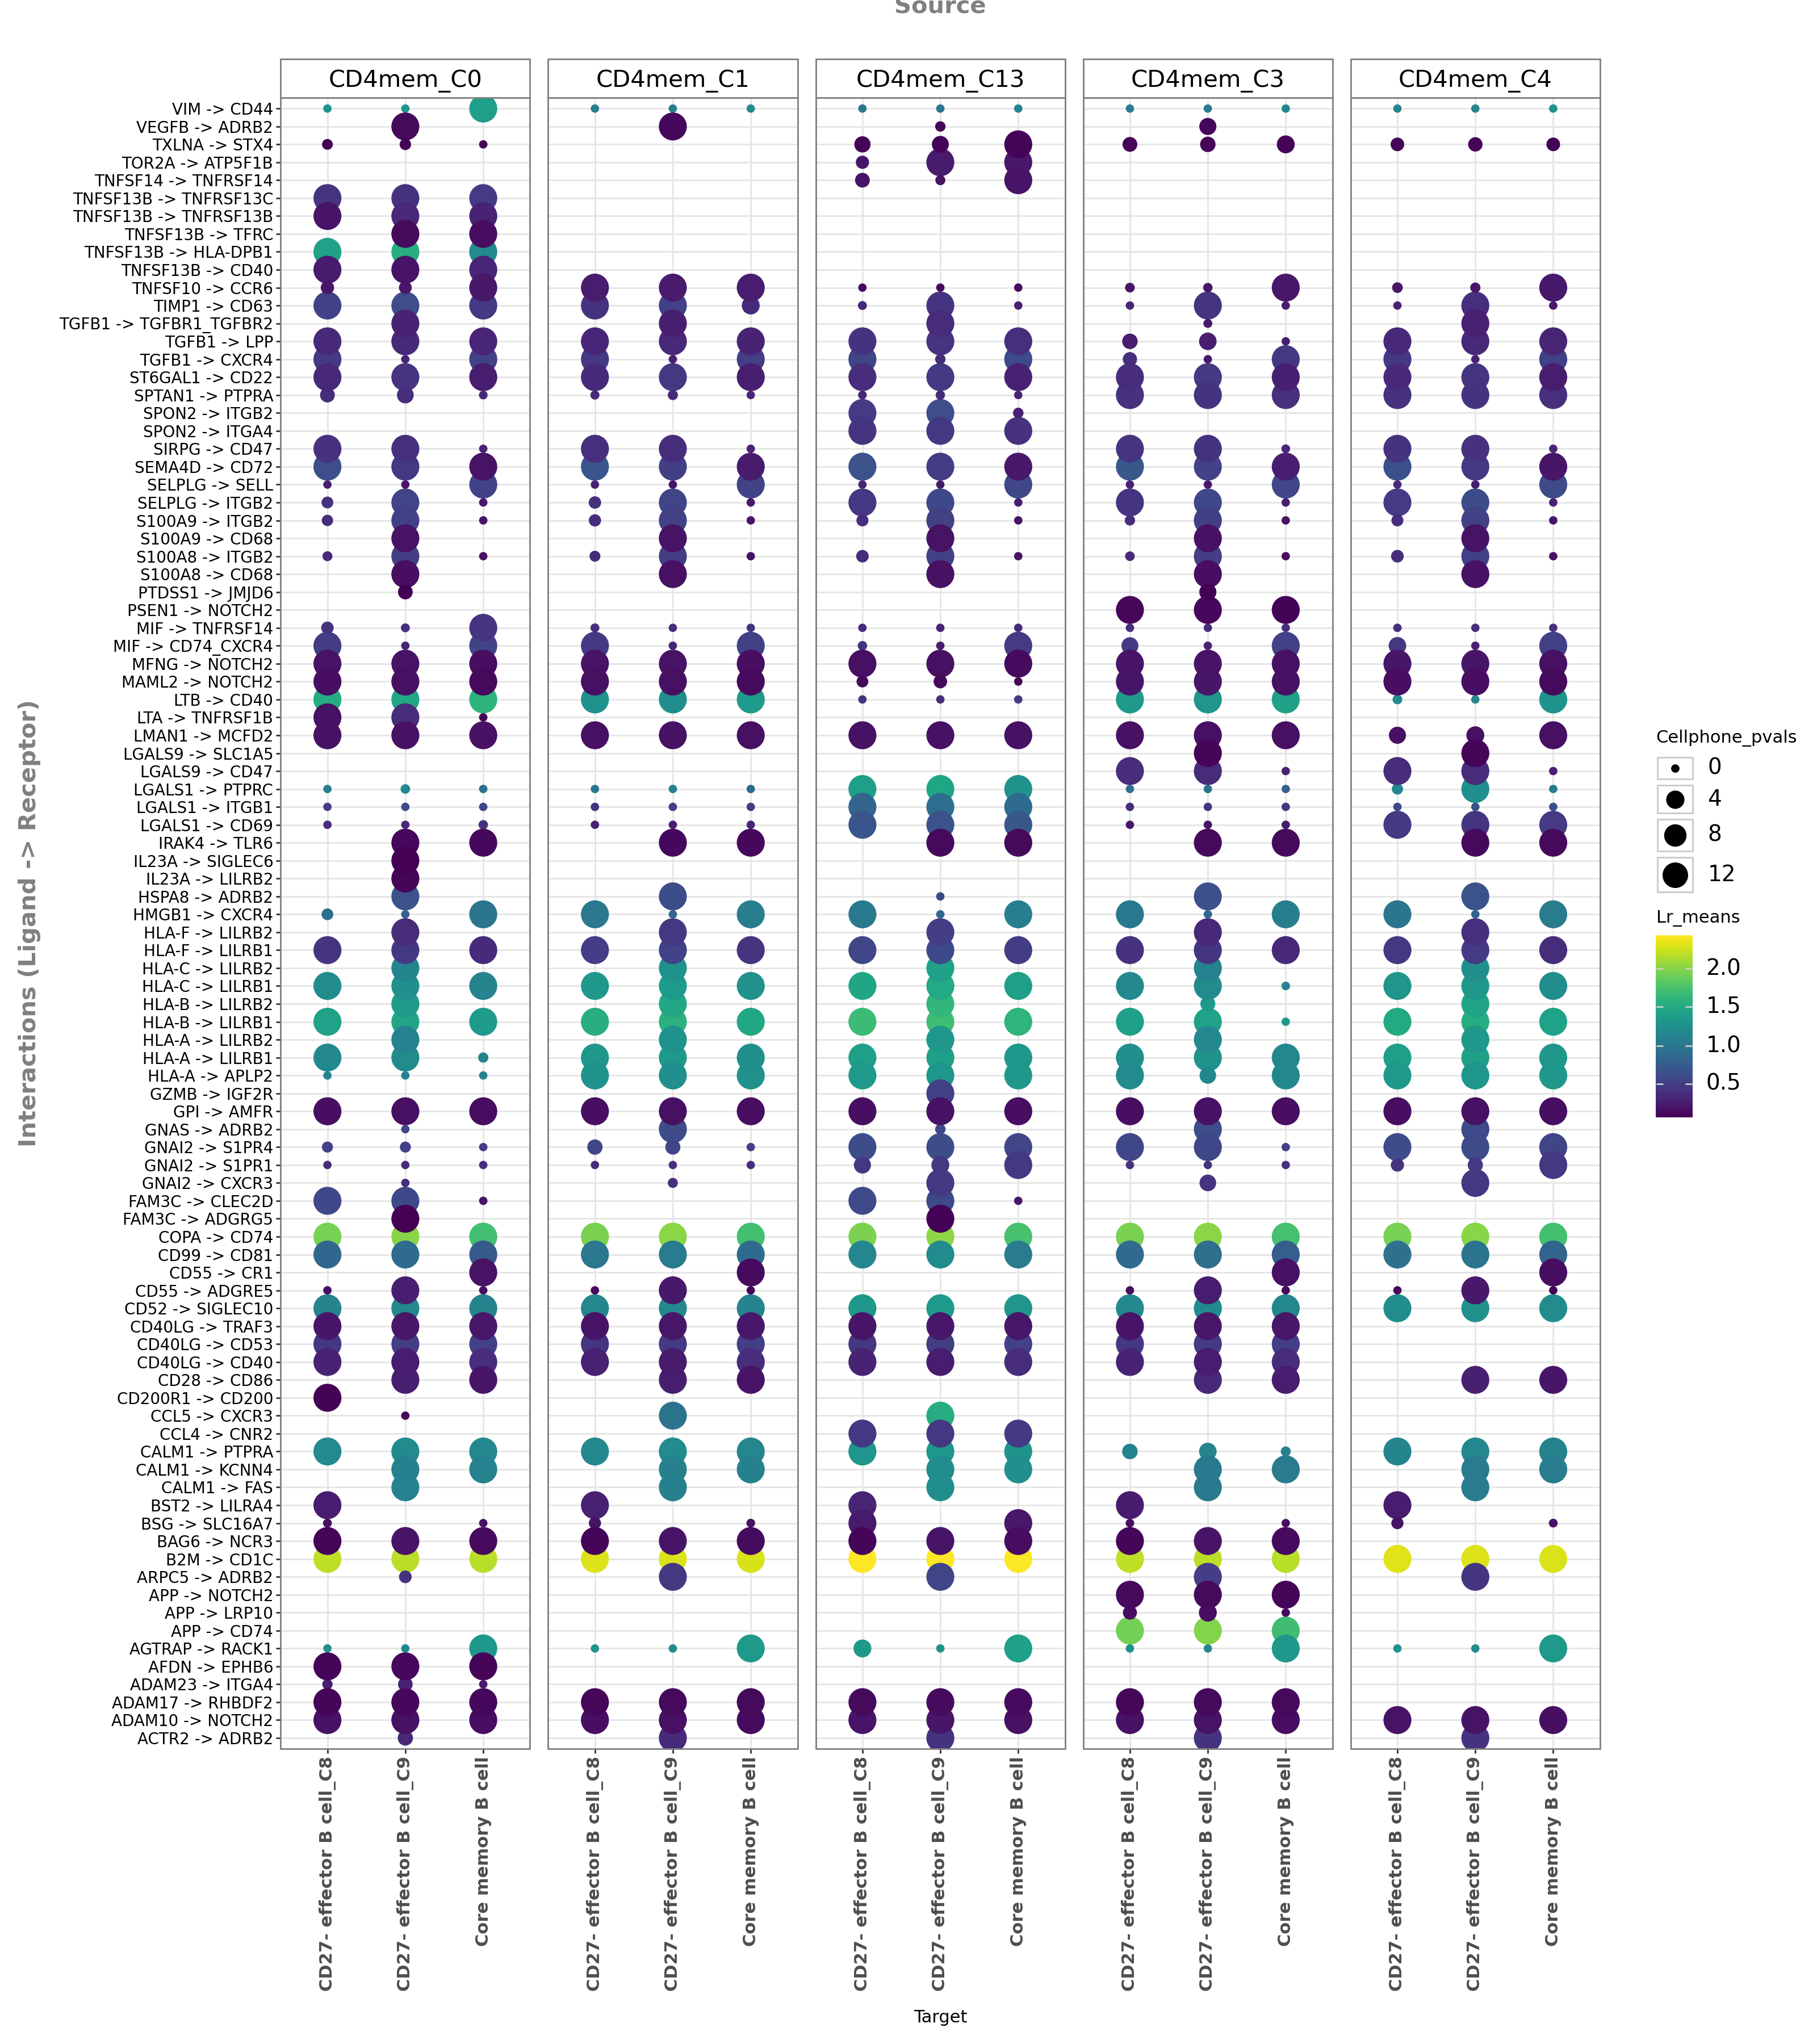

In [ ]:
li.pl.dotplot(adata=tb_adata,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD4mem_C3', 'CD4mem_C4',
                             'CD4mem_C0', 'CD4mem_C13', 'CD4mem_C1'],
              target_labels=['CD27- effector B cell_C8',
                             'CD27- effector B cell_C9', 'Core memory B cell'],
              figure_size=(16, 18),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res'  # uns_key to use, default is 'liana_res'
              )

/home/workspace/environment/liana/lib/python3.11/site-packages/liana/plotting/_common.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


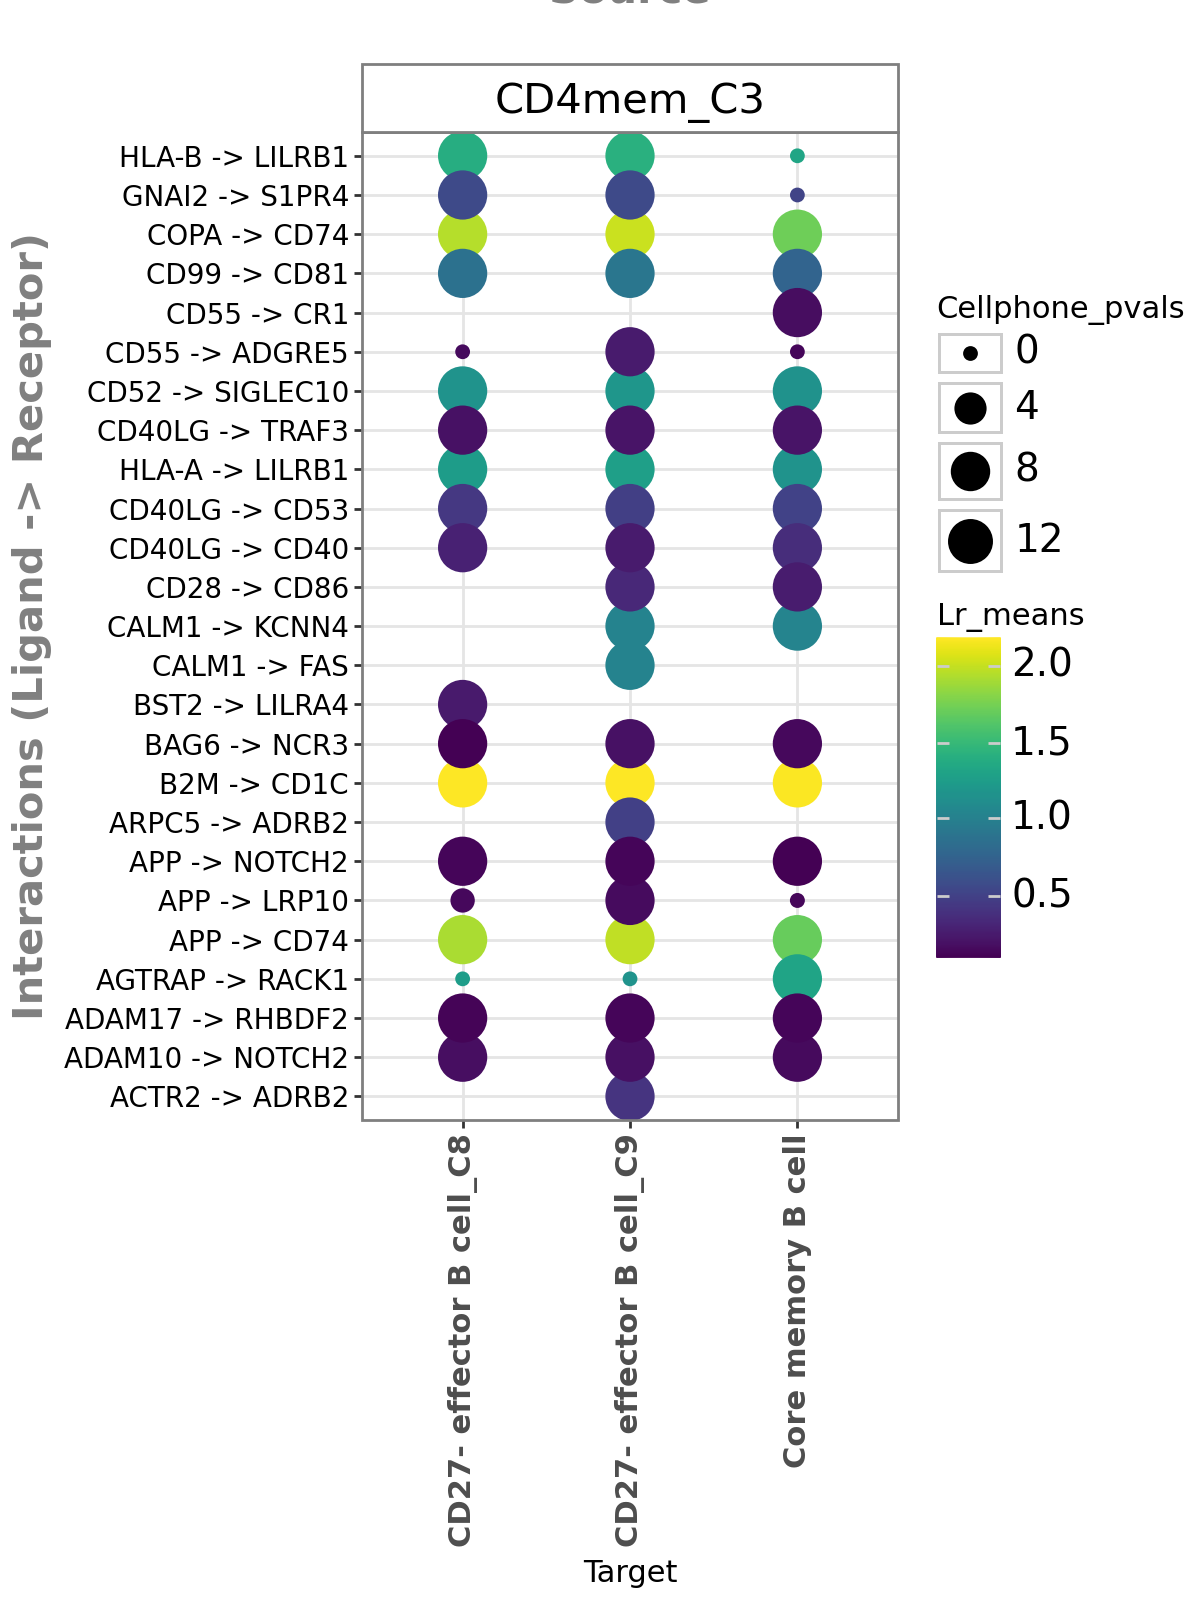

In [ ]:
li.pl.dotplot(adata=tb_adata,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD4mem_C3'],
              target_labels=['CD27- effector B cell_C8',
                             'CD27- effector B cell_C9', 'Core memory B cell'],
              figure_size=(6, 8),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              top_n=25, orderby='cellphone_pvals', orderby_ascending=True,
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.01,
              uns_key='cpdb_res'  # uns_key to use, default is 'liana_res'
              )

In [17]:
# examine the cellphonedb results
tb_adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
40462,B2M,B2M,4.690177,1.000000,CD1C,CD1C,0.596497,0.642368,CD4mem_C13,CD27+ effector B cell,2.643337,0.0
28805,B2M,B2M,4.690177,1.000000,KLRD1,KLRD1,0.505484,0.366557,CD4mem_C13,CD4mem_C13,2.597831,0.0
40208,B2M,B2M,4.480310,1.000000,CD1C,CD1C,0.596497,0.642368,CD4mem_C10,CD27+ effector B cell,2.538404,0.0
39716,B2M,B2M,4.456312,0.998271,CD1C,CD1C,0.596497,0.642368,CD4mem_C4,CD27+ effector B cell,2.526405,0.0
39464,B2M,B2M,4.442906,1.000000,CD1C,CD1C,0.596497,0.642368,CD4mem_C1,CD27+ effector B cell,2.519702,0.0


In [ ]:
# # run cellphonedb
# cellchat(tb_adata,
#             groupby='cell_labels', use_raw=False, n_jobs=30,
#             # NOTE by default the resource uses HUMAN gene symbols
#             resource_name='consensus',
#             expr_prop=0.1,
#             verbose=True, key_added='cellchat_res')

### run liana aggregate methods


In [23]:
li.method.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [24]:
# Run rank_aggregate to aggregate different methods
li.mt.rank_aggregate(tb_adata, use_raw=False, n_perms=5000, n_jobs=30,
                     groupby='cell_labels',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.X`!
/home/workspace/environment/liana/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
6747 features of mat are empty, they will be removed.
/home/workspace/environment/liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/workspace/environment/liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.14 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 247306 samples and 1573 features


/home/workspace/environment/liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 5000/5000 [03:03<00:00, 27.28it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [25]:
tb_adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
20531,CD4mem_C13,CD4mem_C13,HLA-B,CD3D,2.352931,0.0,4.953595,0.733221,0.531772,0.002453,0.973809,0.023462,0.000008
21074,CD4mem_C13,CD4mem_C4,HLA-B,CD3D,2.340172,0.0,4.874079,0.714482,0.538873,0.002413,0.973601,0.023589,0.000010
21001,CD4mem_C13,CD4mem_C3,HLA-B,CD3D,2.337216,0.0,4.855652,0.710145,0.498658,0.002404,0.973553,0.024162,0.000010
20317,CD4mem_C13,CD4mem_C10,HLA-B,CD3D,2.331084,0.0,4.817435,0.701140,0.490716,0.002385,0.973451,0.025284,0.000010
20740,CD4mem_C13,CD4mem_C16,HLA-B,CD3D,2.311842,0.0,4.697509,0.672885,0.442534,0.002326,0.973123,0.029513,0.000014


/home/workspace/environment/liana/lib/python3.11/site-packages/liana/plotting/_common.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 8 in image.
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures/Liana_TB_interaction_global_top25.png


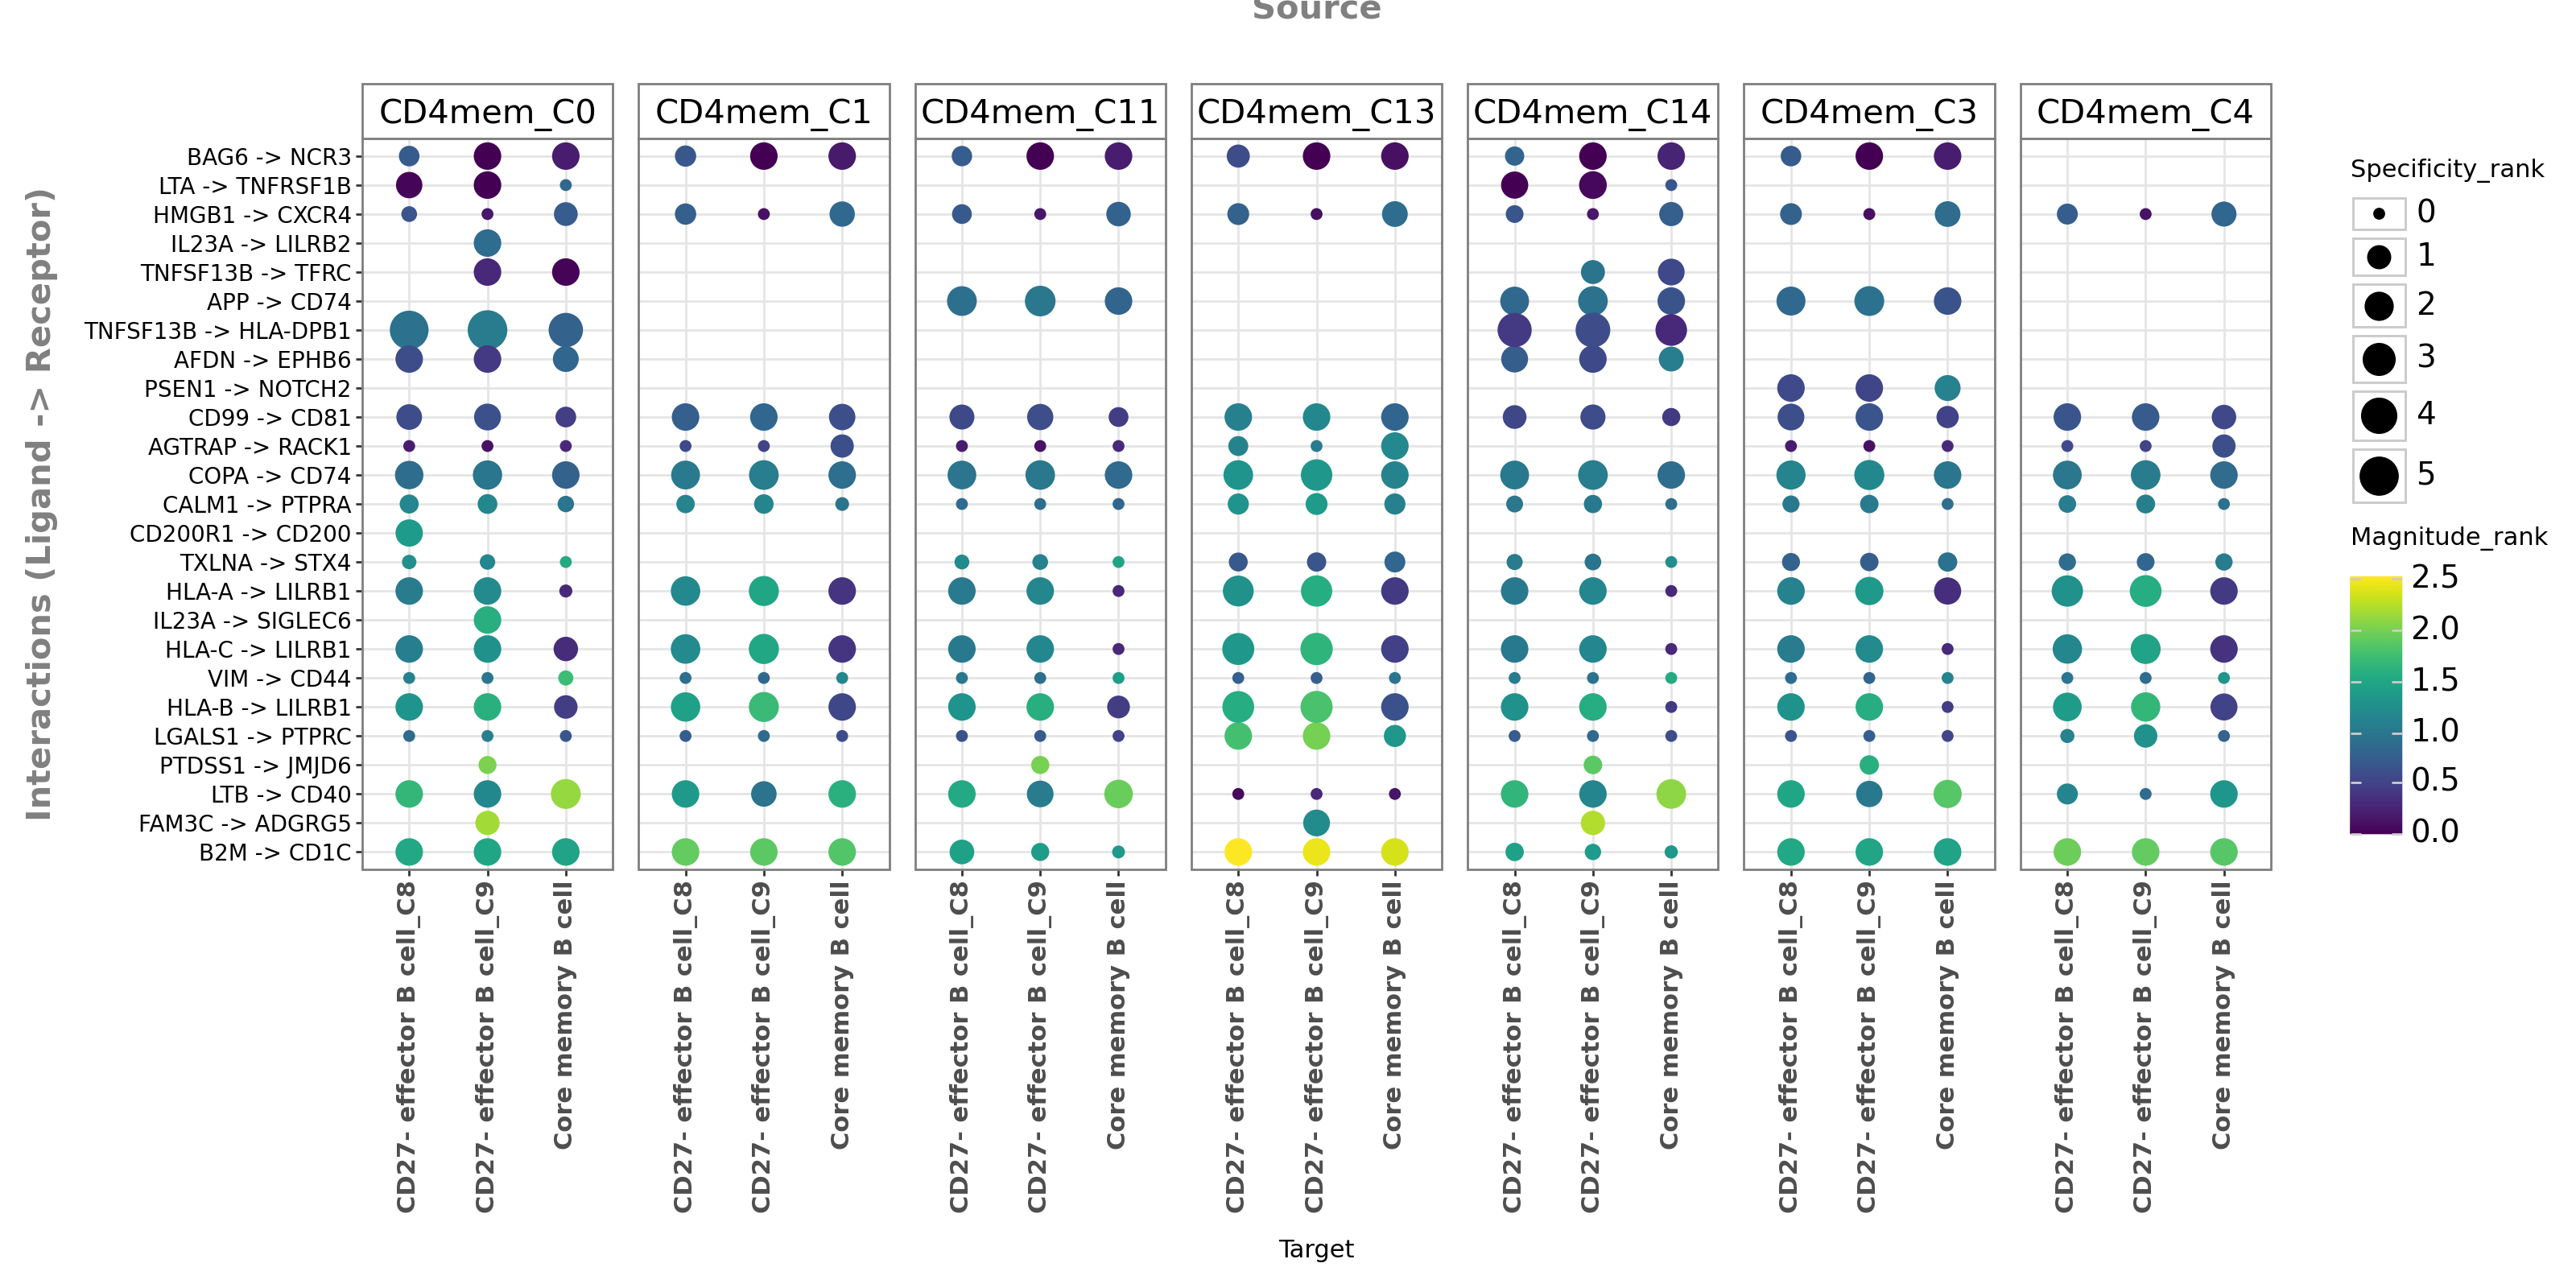

In [ ]:
p1 = li.pl.dotplot(adata=tb_adata,
                   colour='magnitude_rank',
                   size='specificity_rank',
                   inverse_size=True,
                   inverse_colour=True,
                   source_labels=['CD4mem_C3', 'CD4mem_C4', 'CD4mem_C11',
                                  'CD4mem_C13', 'CD4mem_C14', 'CD4mem_C1', 'CD4mem_C0'],
                   target_labels=['CD27- effector B cell_C8',
                                  'CD27- effector B cell_C9', 'Core memory B cell'],
                   top_n=25,
                   orderby='magnitude_rank',
                   orderby_ascending=True,
                   figure_size=(16, 8)
                   )
p1.save(fig_path + 'Liana_TB_interaction_global_top25.png')
p1

/home/workspace/environment/liana/lib/python3.11/site-packages/liana/plotting/_common.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 8 in image.
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures/Liana_BT_interaction_global_top25.png


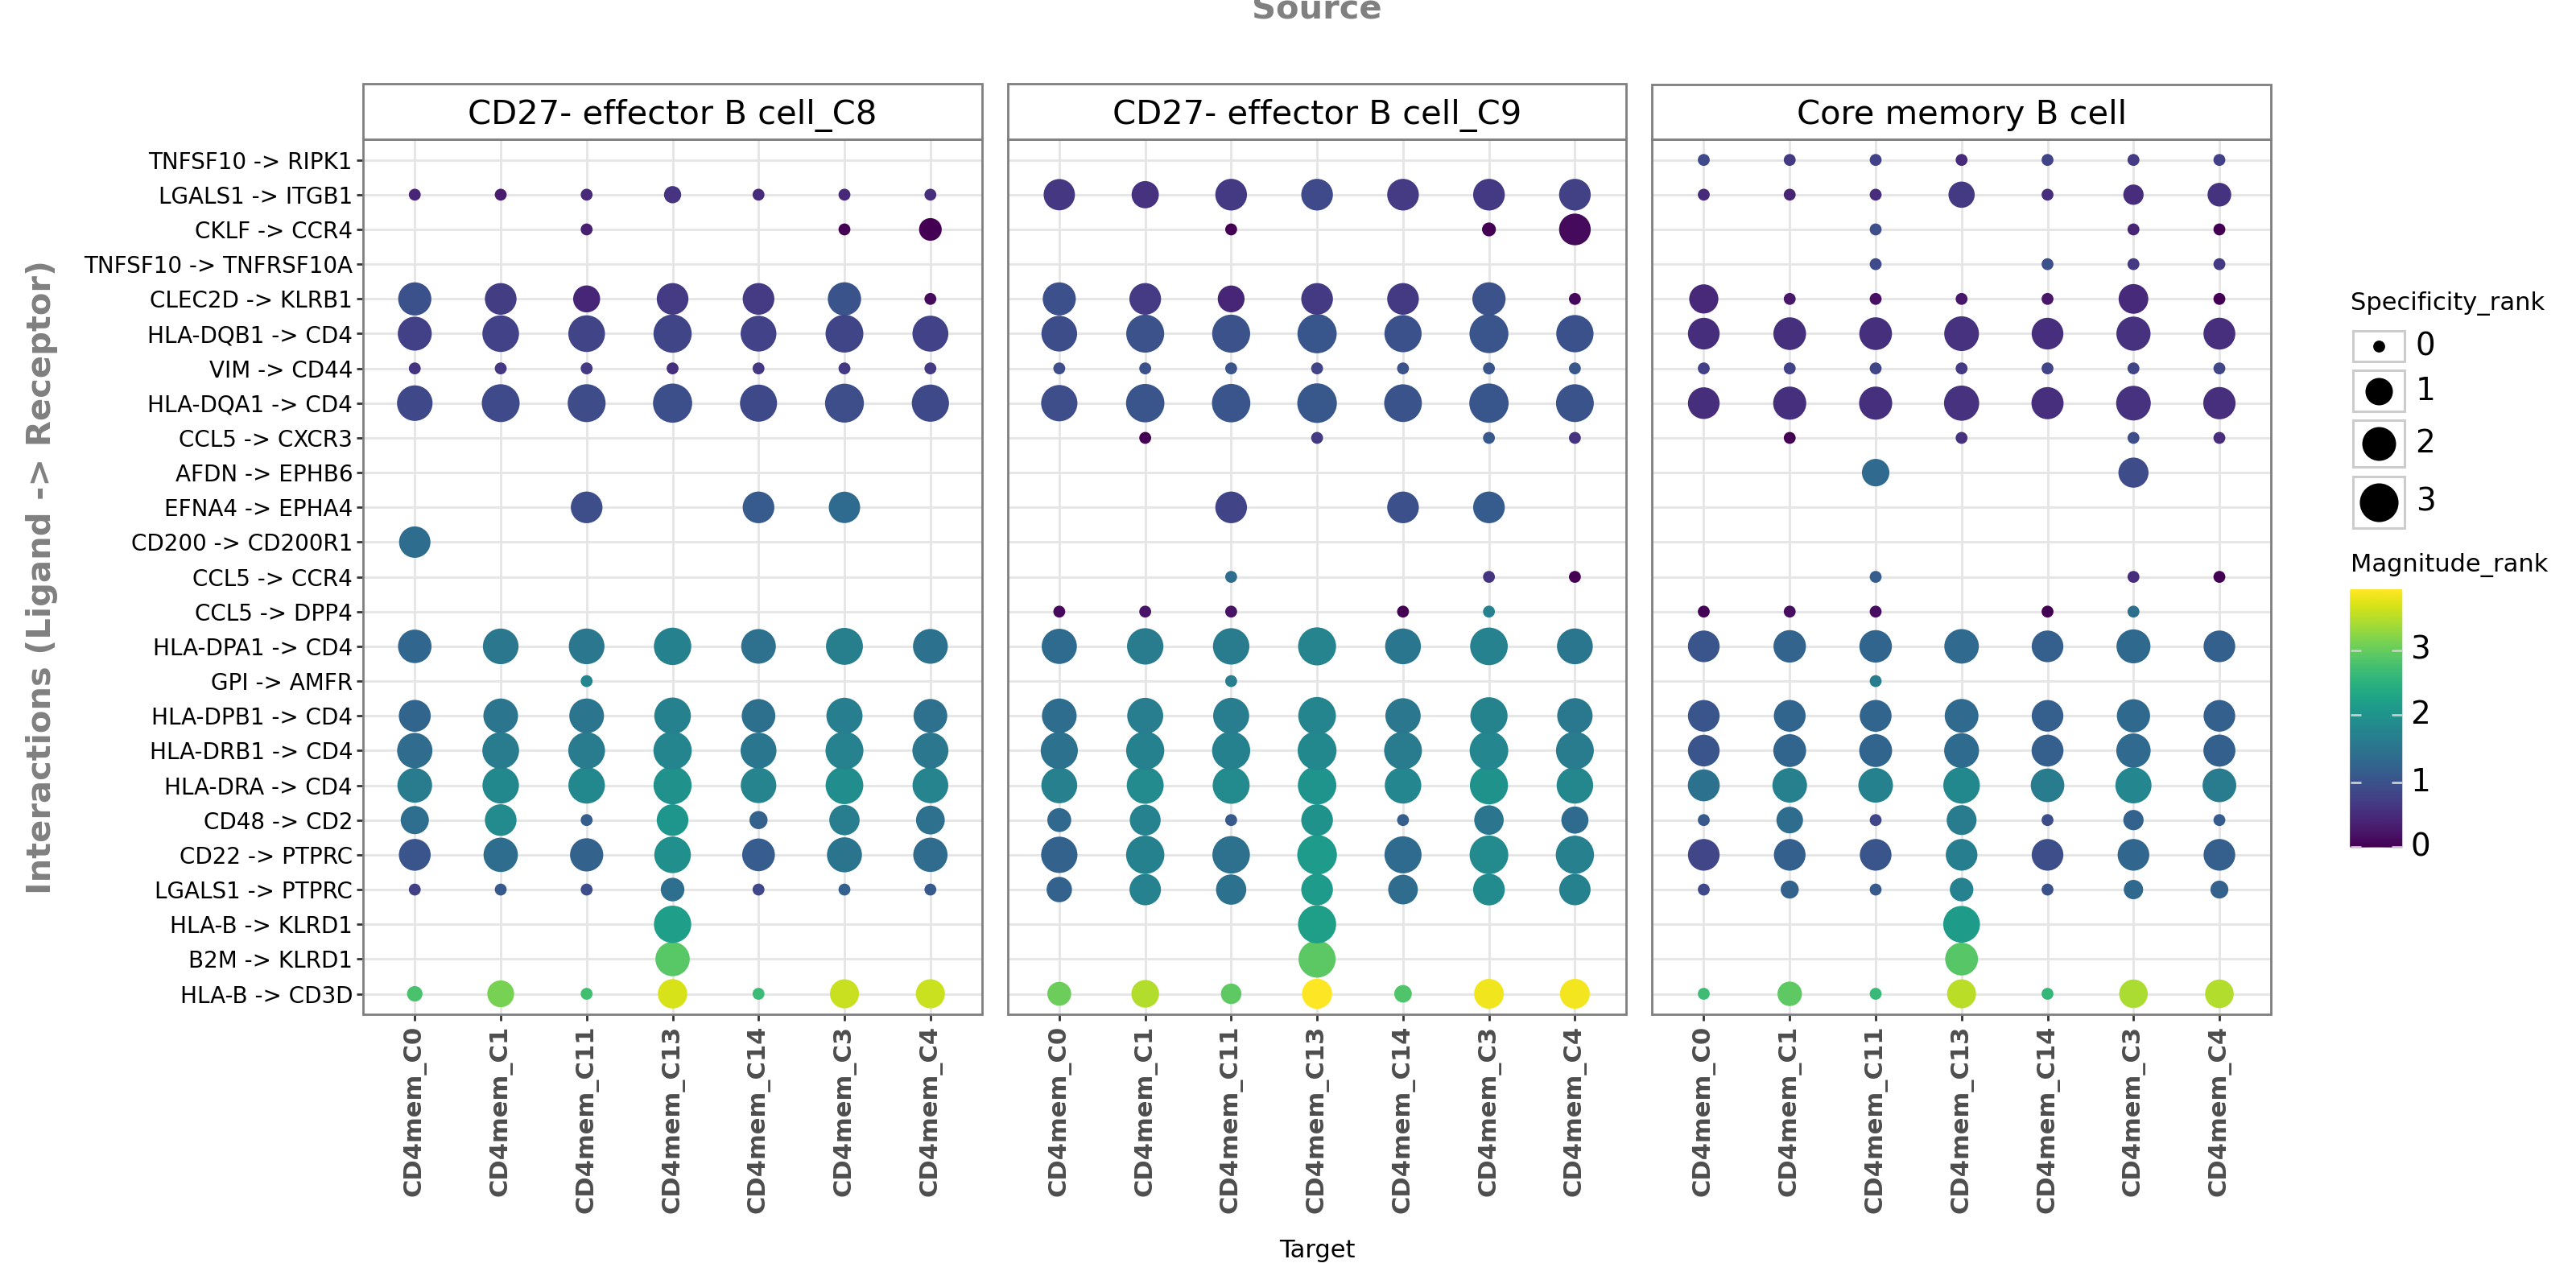

In [ ]:
p1 = li.pl.dotplot(adata=tb_adata,
                   colour='magnitude_rank',
                   size='specificity_rank',
                   inverse_colour=True,  # we inverse sign since we want small p-values to have large sizes
                   inverse_size=True,
                   source_labels=['CD27- effector B cell_C8', 'CD27- effector B cell_C9', 'Core memory B cell'
                                  ],
                   target_labels=['CD4mem_C3', 'CD4mem_C4', 'CD4mem_C11',
                                  'CD4mem_C13', 'CD4mem_C14', 'CD4mem_C1', 'CD4mem_C0'],
                   top_n=25,
                   orderby='magnitude_rank',
                   orderby_ascending=True,
                   figure_size=(16, 8)
                   )
p1.save(fig_path + 'Liana_BT_interaction_global_top25.png')
p1

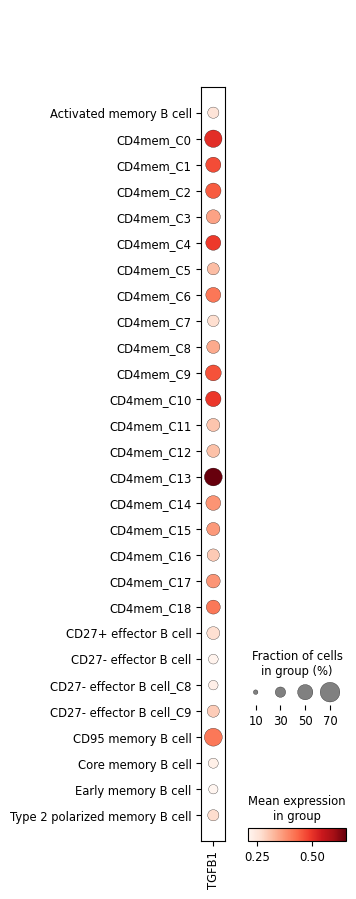

In [ ]:
sc.pl.dotplot(tb_adata, ['TGFB1'], groupby='cell_labels')

/home/workspace/environment/liana/lib/python3.11/site-packages/liana/plotting/_common.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 8 in image.
/home/workspace/environment/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures/Liana_TB_interaction_CD4mem_C3toBem_top25.png


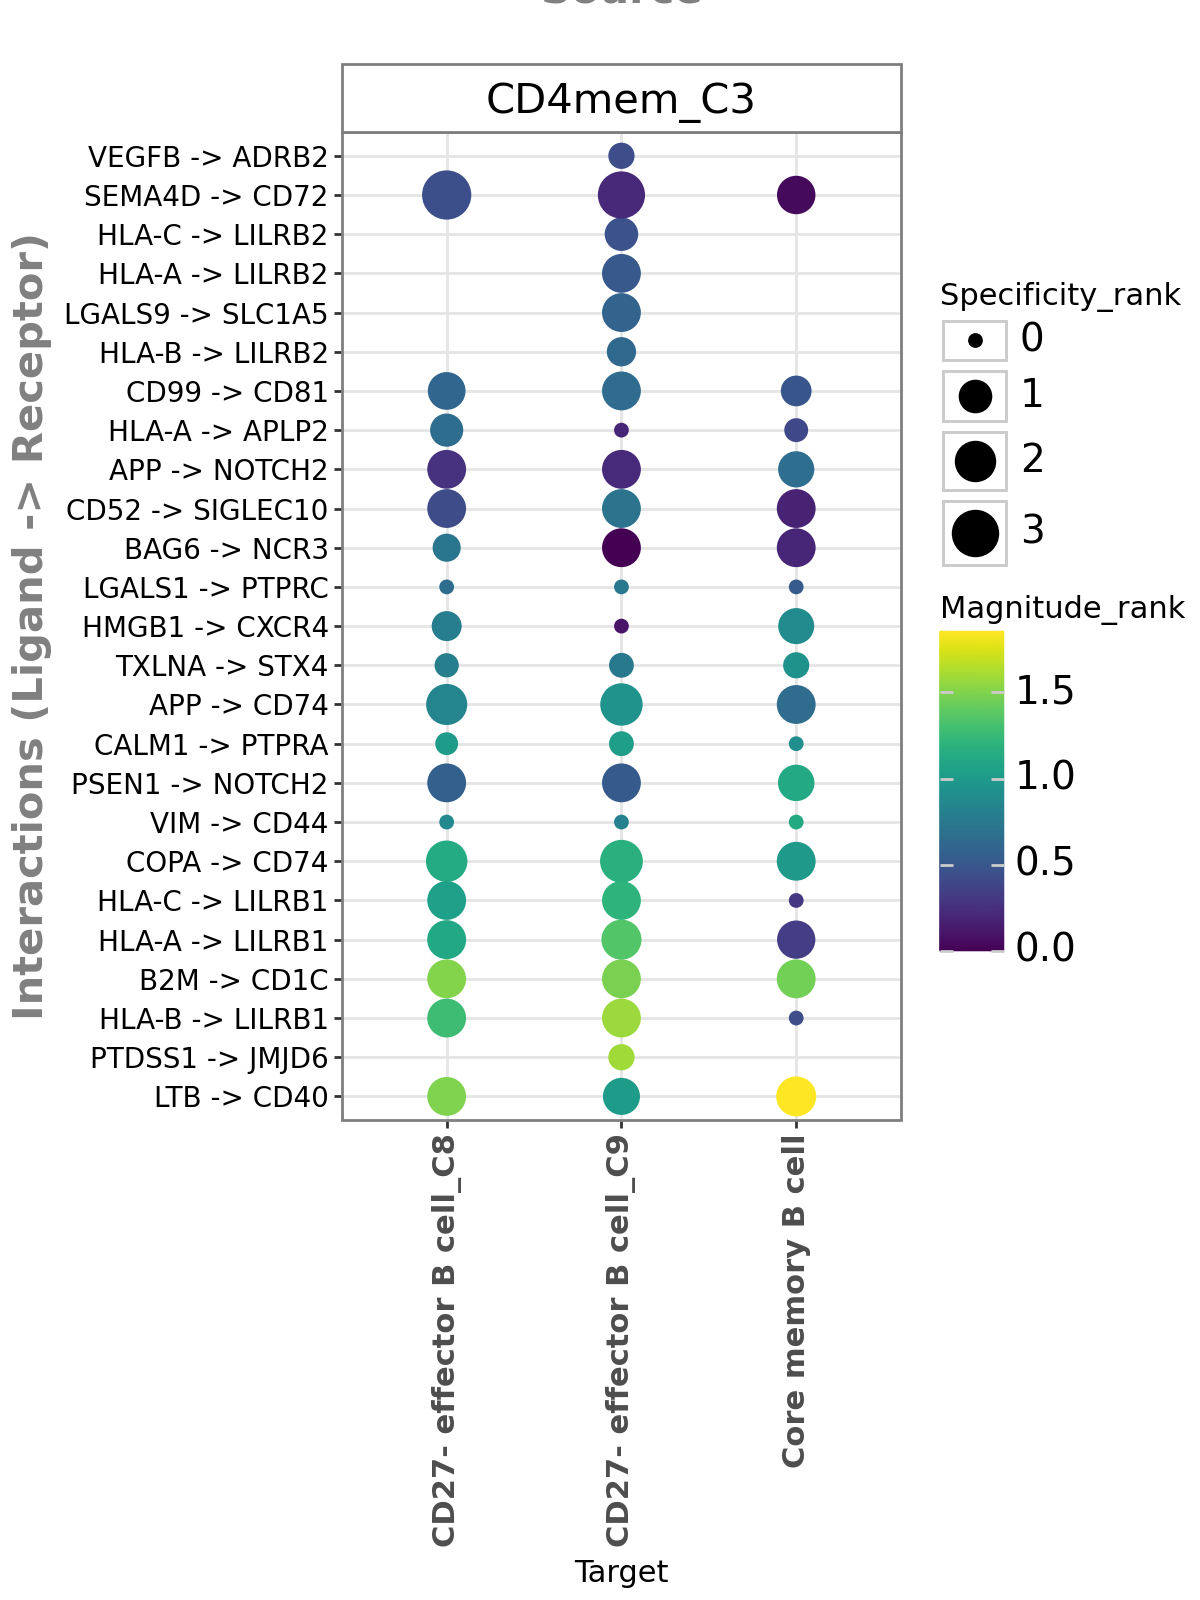

### Run rank_aggregate to aggregate different methods for aifi l3


In [34]:
tb_adata

AnnData object with n_obs × n_vars = 247306 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'St

In [ ]:
li.mt.rank_aggregate(tb_adata, use_raw=False, key_added='liana_res_l3',
                     groupby='AIFI_L3',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.X`!
/home/workspace/environment/minimal/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
6747 features of mat are empty, they will be removed.
/home/workspace/environment/minimal/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/workspace/environment/minimal/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.14 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 247306 samples and 1573 features


/home/workspace/environment/minimal/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [02:25<00:00,  6.89it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [36]:
tb_adata.uns['liana_res_l3'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
18843,KLRF1- GZMB+ CD27- memory CD4 T cell,KLRB1+ memory CD4 Treg,HLA-B,CD3D,2.417171,0.0,5.330019,0.833576,0.603495,0.007699,0.974726,0.040419,0.000008
19106,KLRF1- GZMB+ CD27- memory CD4 T cell,Proliferating T cell,HLA-B,CD3D,2.402034,0.0,5.235167,0.811348,0.561032,0.007562,0.974504,0.040419,0.000009
18931,KLRF1- GZMB+ CD27- memory CD4 T cell,KLRF1- GZMB+ CD27- memory CD4 T cell,HLA-B,CD3D,2.366244,0.0,5.010894,0.758786,0.545108,0.007238,0.973955,0.040419,0.000015
19010,KLRF1- GZMB+ CD27- memory CD4 T cell,Memory CD4 Treg,HLA-B,CD3D,2.341806,0.0,4.857756,0.722897,0.546739,0.007017,0.973558,0.040419,0.000024
18694,KLRF1- GZMB+ CD27- memory CD4 T cell,GZMK+ memory CD4 Treg,HLA-B,CD3D,2.324795,0.0,4.751153,0.697917,0.498386,0.006863,0.973271,0.040419,0.000029


/home/workspace/environment/minimal/lib/python3.11/site-packages/liana/plotting/_common.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


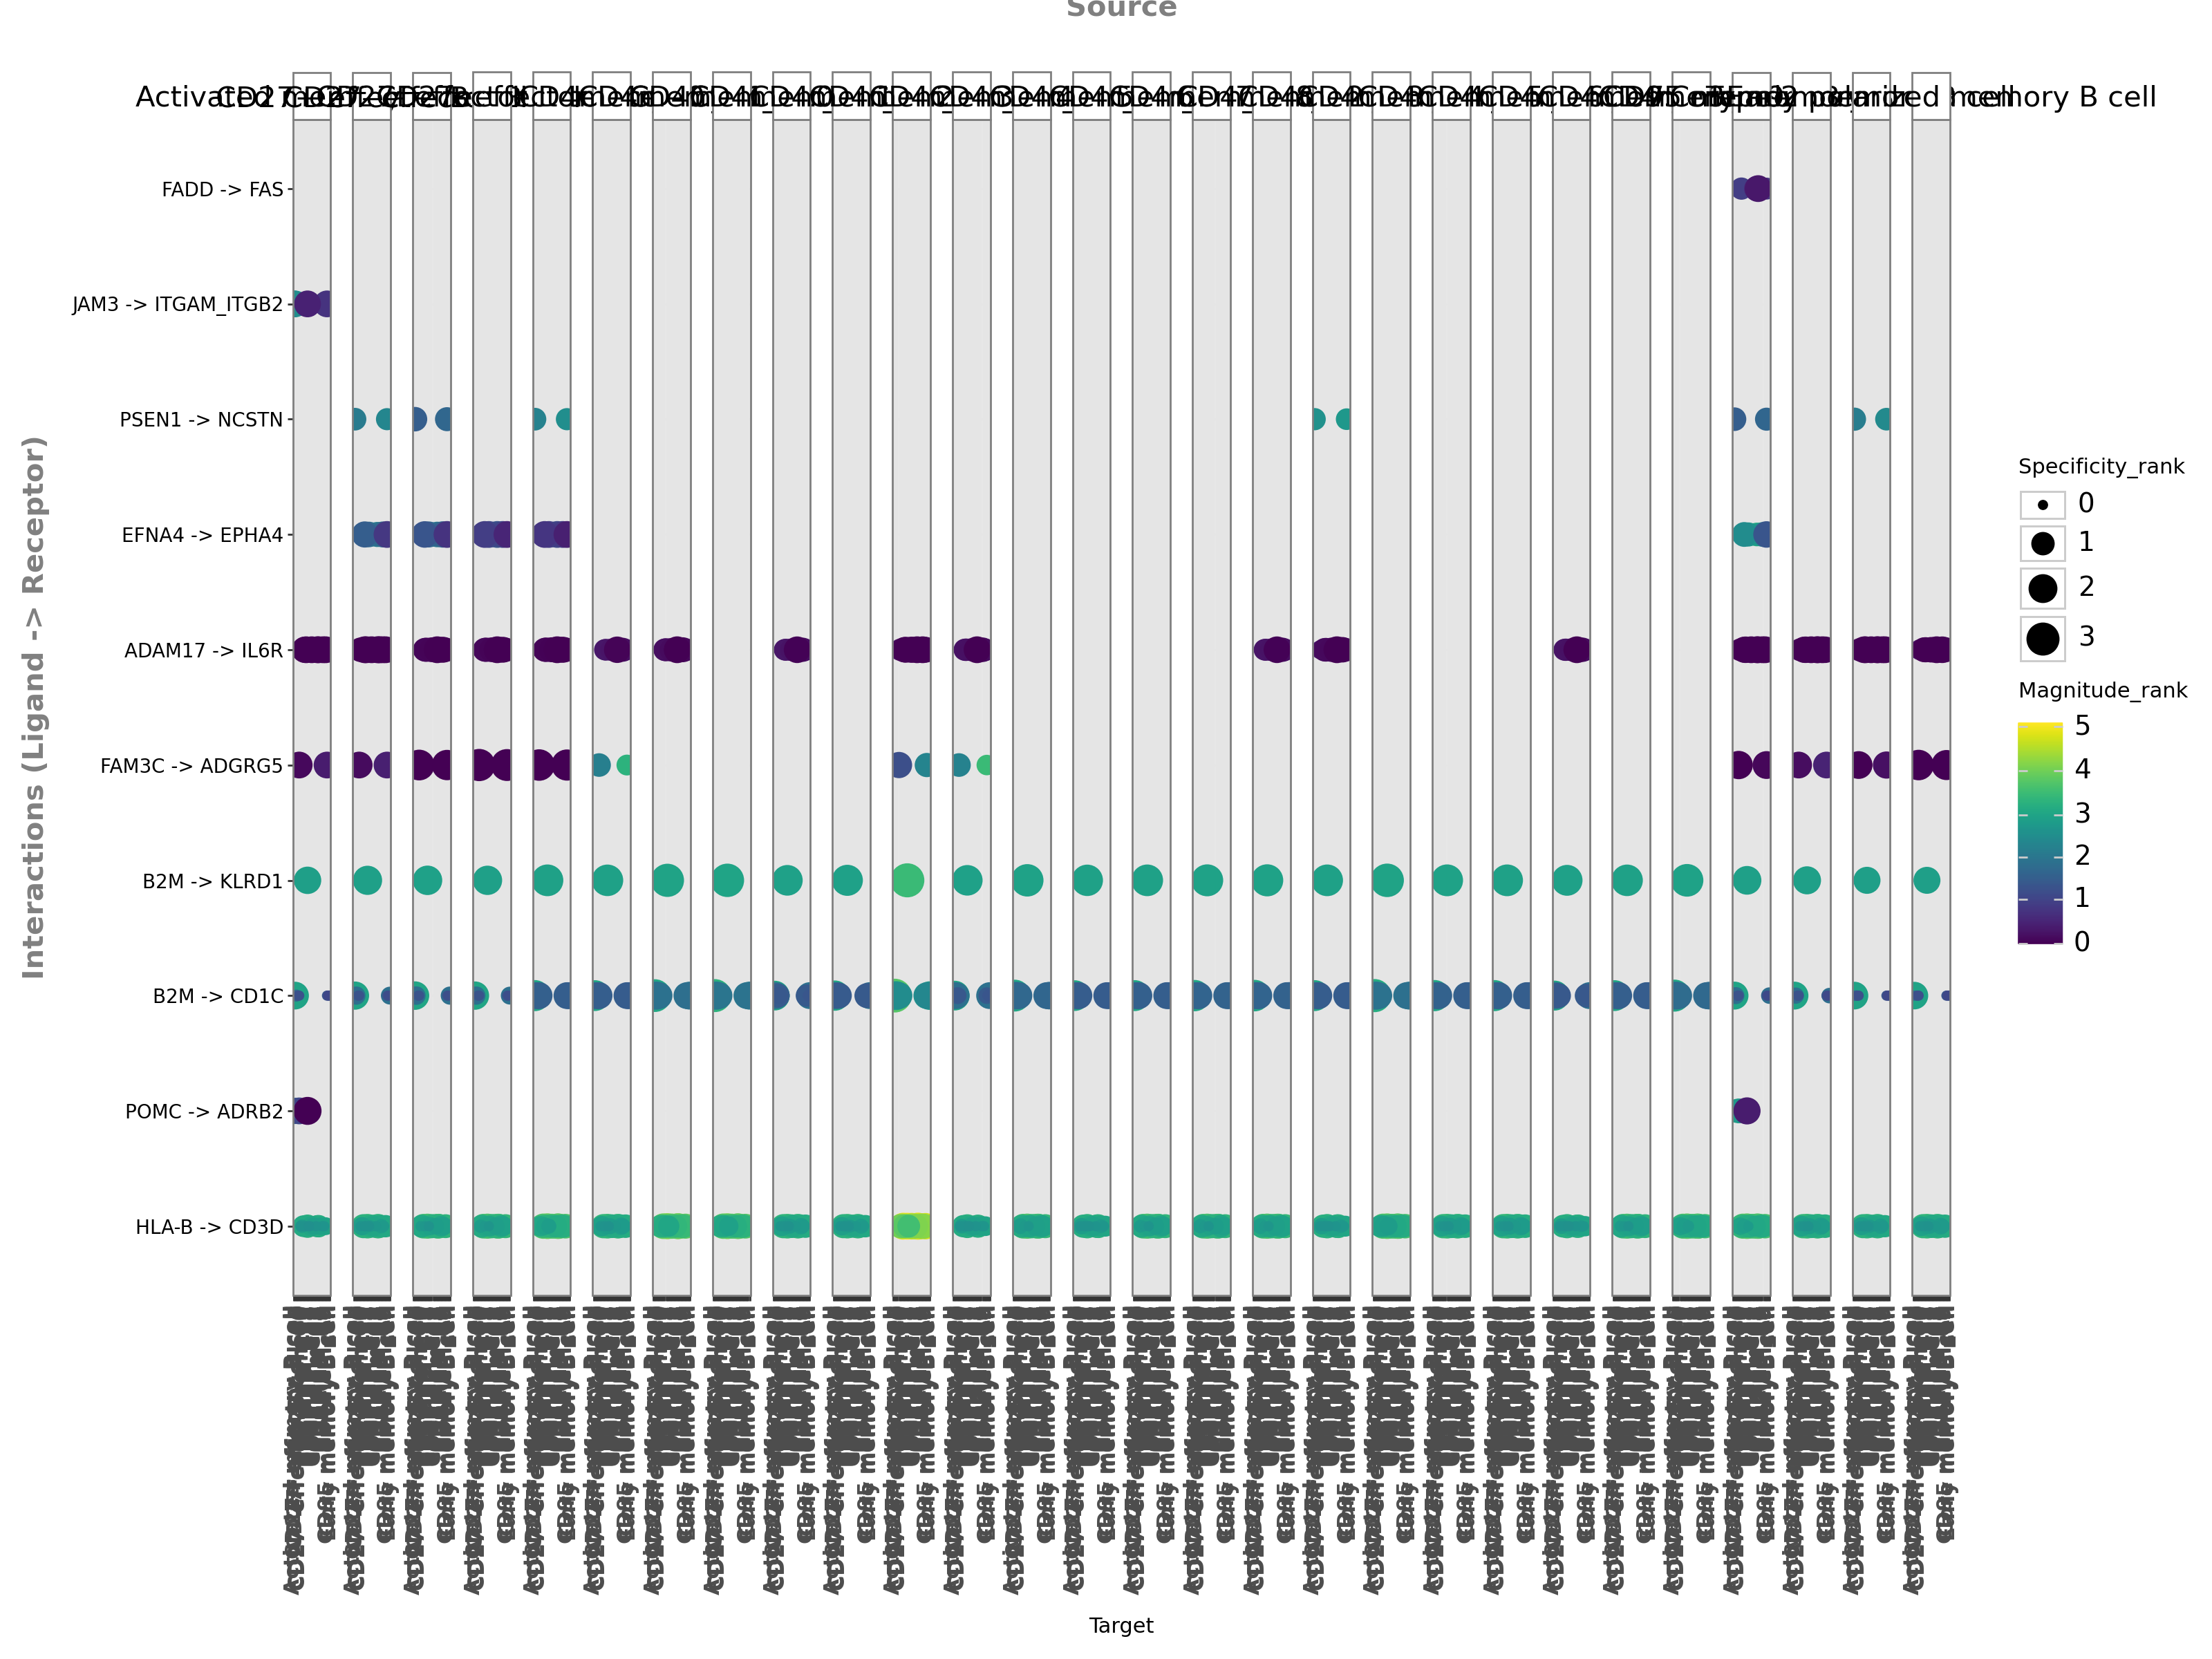

In [ ]:
li.pl.dotplot(adata=tb_adata, liana_res='liana_res_l3',
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              # source_labels=['CD4mem_C3', 'CD4mem_C4','CD4mem_C13', 'CD4mem_C14', 'CD4mem_C1', 'CD4mem_C0'],
              #  target_labels=[ 'CD27- effector B cell_C8', 'CD27- effector B cell_C9', 'Core memory B cell'],
              top_n=10,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(16, 12)
              )

In [ ]:
# save the data
tb_adata.write_h5ad(
    '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/ALTRA_aim3_T_B_mem_cells_liana.h5ad')